In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_excel("Customer_churn.xlsx")

In [3]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [4]:
df.shape

(7043, 33)

In [5]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [7]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [8]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df=df.drop(columns=['CustomerID','Count',"Country",'State','City','Zip Code','Lat Long','Latitude','Longitude','Churn Score','CLTV','Churn Reason'])

In [11]:
df.columns

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label',
       'Churn Value'],
      dtype='object')

In [12]:
df.shape

(7043, 21)

In [13]:
df['Churn Label'].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

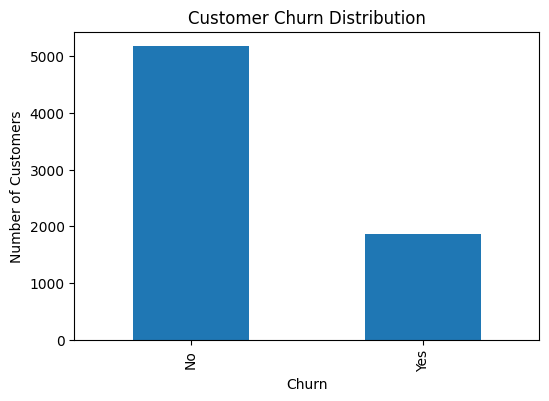

In [14]:
plt.figure(figsize=(6,4))
df['Churn Label'].value_counts().plot(kind='bar')
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

In [15]:
pd.crosstab(df['Gender'],df['Churn Label'])

Churn Label,No,Yes
Gender,,
Female,2549,939
Male,2625,930


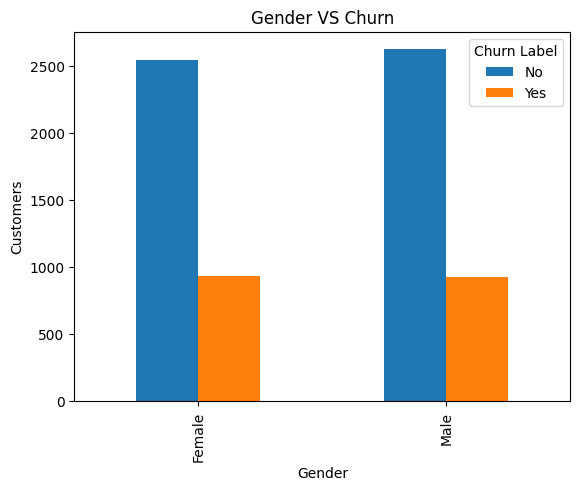

In [16]:
pd.crosstab(df['Gender'],df['Churn Label']).plot(kind='bar')
plt.title("Gender VS Churn")
plt.xlabel("Gender")
plt.ylabel("Customers")
plt.show()

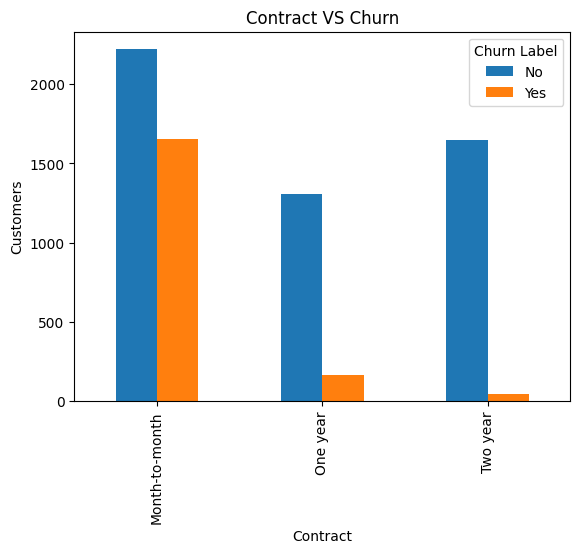

In [17]:
pd.crosstab(df['Contract'],df['Churn Label']).plot(kind='bar')
plt.title("Contract VS Churn")
plt.xlabel("Contract")
plt.ylabel("Customers")
plt.show()


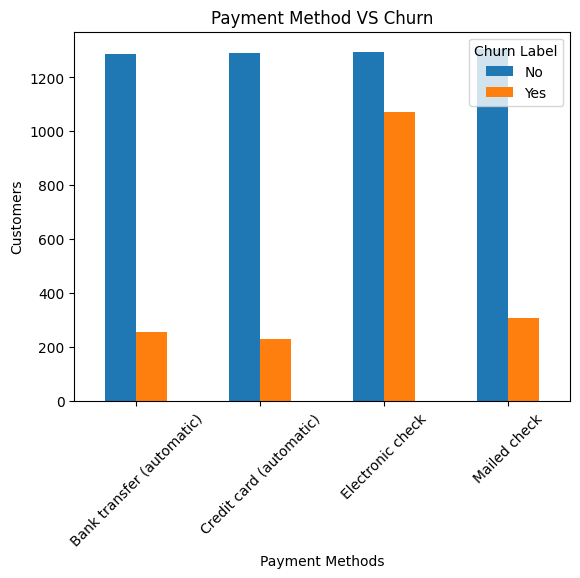

<Figure size 640x480 with 0 Axes>

In [18]:
pd.crosstab(df['Payment Method'],df['Churn Label']).plot(kind='bar')
plt.title("Payment Method VS Churn")
plt.xlabel("Payment Methods")
plt.ylabel("Customers")
plt.xticks(rotation=45)
plt.show()
plt.savefig("Payment Method VS Churn.png")

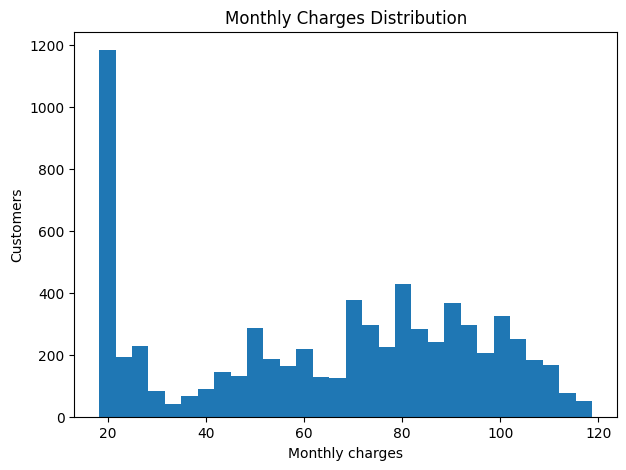

In [19]:
plt.figure(figsize=(7,5))
plt.hist(df['Monthly Charges'],bins=30)
plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly charges")
plt.ylabel("Customers")
plt.show()

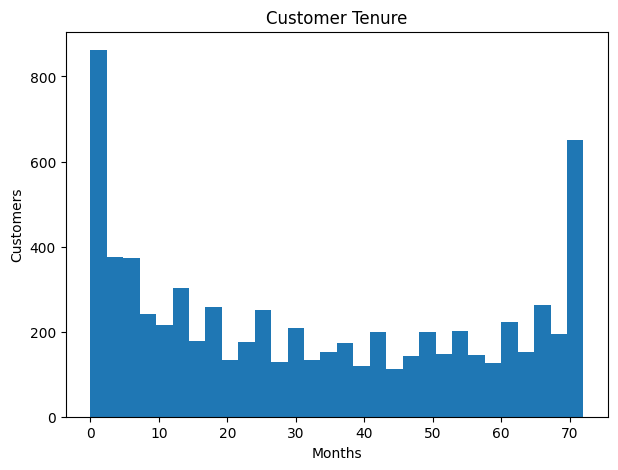

In [20]:
plt.figure(figsize=(7,5))
plt.hist(df['Tenure Months'],bins=30)
plt.title("Customer Tenure")
plt.xlabel("Months")
plt.ylabel("Customers")
plt.show()

In [21]:
df['Risk Category']=pd.cut(df['Monthly Charges'],bins=[0,40,80,130],labels=['low','Medium','High'])

In [22]:
df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Risk Category
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,Medium
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,Medium
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,High
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,High
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,...,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,High


In [23]:
df['Risk Category'].value_counts()

Risk Category
High      2666
Medium    2539
low       1838
Name: count, dtype: int64

In [24]:
x=df.drop(columns=['Churn Label','Churn Value'])
y=df['Churn Value']

In [25]:
print(x.shape)
print(y.shape)

(7043, 20)
(7043,)


In [26]:
x.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Risk Category
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Medium
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Medium
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,High
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,High
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,High


In [27]:
categorical_cols=x.select_dtypes(include='object').columns
numerical_cols=x.select_dtypes(exclude='object').columns

print(f"Categorical Columns:{categorical_cols}")
print(f"Numerical Coulumns:{numerical_cols}")

Categorical Columns:Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Total Charges'],
      dtype='object')
Numerical Coulumns:Index(['Tenure Months', 'Monthly Charges', 'Risk Category'], dtype='object')


In [28]:
x['Total Charges']=pd.to_numeric(x['Total Charges'],errors='coerce')


In [29]:
print(x['Total Charges'].dtype)

print(x['Total Charges'].isnull().sum())

float64
11


In [30]:
x[x['Total Charges'].isnull()][["Tenure Months","Monthly Charges","Total Charges"]]

,Tenure Months,Monthly Charges,Total Charges
2234,0,52.55,NaN
2438,0,20.25,NaN
2568,0,80.85,NaN
2667,0,25.75,NaN
2856,0,56.05,NaN
4331,0,19.85,NaN
4687,0,25.35,NaN
5104,0,20.00,NaN
5719,0,19.70,NaN
6772,0,73.35,NaN


In [31]:
x['Total Charges']=x['Total Charges'].fillna(0)

In [32]:
print(x['Total Charges'].isnull().sum())

0


In [33]:
from sklearn.model_selection import  train_test_split

X_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [34]:
print("X_train:",X_train.shape)
print("X_Test:",x_test.shape)
print("Y_train:",y_train.shape)
print("Y_Test:",y_test.shape)

X_train: (5634, 20)
X_Test: (1409, 20)
Y_train: (5634,)
Y_Test: (1409,)


In [35]:
from sklearn.preprocessing import OneHotEncoder

In [36]:
categorical_cols=x.select_dtypes(include='object').columns.tolist()
categorical_cols.append("Risk Category")

In [37]:
numerical_cols=x.select_dtypes(exclude='object').columns.tolist()
numerical_cols.remove('Risk Category')

In [38]:
print("Categorical Columns:",categorical_cols)
print("Numerical Columns:",numerical_cols)

Categorical Columns: ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Risk Category']
Numerical Columns: ['Tenure Months', 'Monthly Charges', 'Total Charges']


In [39]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

In [40]:
preprocessor=ColumnTransformer(transformers=[('cat',OneHotEncoder(handle_unknown='ignore'),categorical_cols),('num',StandardScaler(),numerical_cols)])

In [41]:
X_train_processed=preprocessor.fit_transform(X_train)

In [42]:
x_test_processed=preprocessor.transform(x_test)

In [43]:
print("X_train_processed:",X_train_processed.shape)
print("x_test_processed:",x_test_processed.shape)

X_train_processed: (5634, 49)
x_test_processed: (1409, 49)


In [44]:
from sklearn.linear_model import LogisticRegression

In [45]:
model=LogisticRegression(max_iter=1000)
model.fit(X_train_processed,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [46]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

y_pred=model.predict(x_test_processed)
print("Accuracy:",accuracy_score(y_test,y_pred))

print("\nClassification Report:")
print(classification_report(y_test,y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test,y_pred))

Accuracy: 0.8034066713981547

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.88      0.87      1035
           1       0.64      0.58      0.61       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409


Confusion Matrix:
[[915 120]
 [157 217]]


In [47]:
from sklearn.tree import DecisionTreeClassifier

dt_model=DecisionTreeClassifier(random)

NameError: name 'random' is not defined